In [10]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

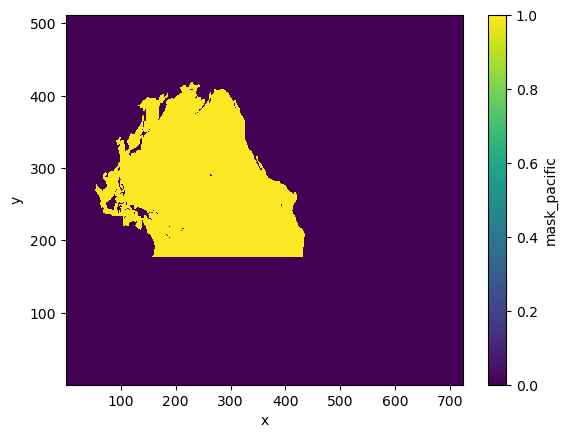

In [11]:
archive = '/gxfs_work/geomar/smomw723/EddiesHC_analysis/'
basin_mask = xr.open_mfdataset(archive + 'ORCA3.4-05_ocean_basin_masks.nc')
basin_mask.mask_pacific.plot()

y.DataArray 'model' ()> Size: 60B
[1 values with dtype=<U15]
Coordinates:
    model    <U15 60B .
ACCESS-CM2
y.DataArray 'model' ()> Size: 60B
[1 values with dtype=<U15]
Coordinates:
    model    <U15 60B .
ACCESS-ESM1-5
y.DataArray 'model' ()> Size: 60B
[1 values with dtype=<U15]
Coordinates:
    model    <U15 60B .
CAMS-CSM1-0
y.DataArray 'model' ()> Size: 60B
[1 values with dtype=<U15]
Coordinates:
    model    <U15 60B .
CanESM5
y.DataArray 'model' ()> Size: 60B
[1 values with dtype=<U15]
Coordinates:
    model    <U15 60B .
CESM2
y.DataArray 'model' ()> Size: 60B
[1 values with dtype=<U15]
Coordinates:
    model    <U15 60B .
CESM2-WACCM
y.DataArray 'model' ()> Size: 60B
[1 values with dtype=<U15]
Coordinates:
    model    <U15 60B .
CNRM-ESM2-1
y.DataArray 'model' ()> Size: 60B
[1 values with dtype=<U15]
Coordinates:
    model    <U15 60B .
EC-Earth3
y.DataArray 'model' ()> Size: 60B
[1 values with dtype=<U15]
Coordinates:
    model    <U15 60B .
EC-Earth3-Veg
y.DataArray 'model'

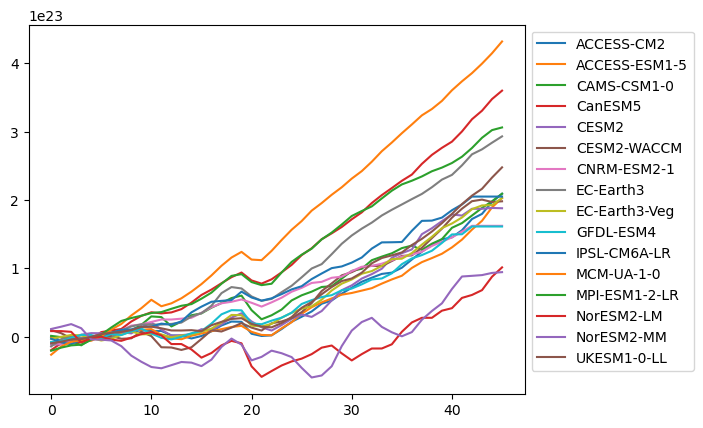

In [12]:
archive = '/gxfs_work/geomar/smomw723/'
a = xr.open_mfdataset(archive + 'EddiesHC_analysis/OHC_2000m_CMIP6.nc') 
length=43
cmip = np.empty([length, 25])
cmip_shading = np.zeros(shape=(length,5)) # empty array which I then fill up
cmip_shading[:,0] = np.linspace(1972,2014,43) # first column = year data
                                              # second column = mean

# rolling mean over five time steps
CMIP_hist = xr.open_dataset(archive + 'EddiesHC_analysis/OHC_2000m_CMIP6.nc', decode_times=True).dropna('y')
CMIP_ssps = xr.open_dataset(archive + 'EddiesHC_analysis/SSP5_85_OHCchange_0_2000m.nc', decode_times=True)

# selecting the models which do have both hist + ssps data
length=43+3 # historical 1970-2014 + 2015-2099 period lengths
cmip = np.empty([length, 16]) # 16 members
cmip_shading = np.zeros(shape=(length,5)) # empty array which I then fill up
cmip_shading[:,0] = np.linspace(1972,2017,length) # first column = year data
                                              # second column = mean   

hist_model_index = [0,1,2,3,5,7,10,11,12,13,16,17,19,21,22,24]
ssps_model_index = [0,1,2,3,4,5, 9,10,11,13,15,16,17,18,19,20]

for f in range(len(hist_model_index)): # loop through the models
    cmip[0:43,f] = CMIP_hist.OHC_2000m[hist_model_index[f]].values[2:]        # select 1970-2014 for each ensemble
    # from Taimoor: As this data has been dedrifted, you will need to have the SSP[t=0] match hist[t=-1].
    # here I shift the data so that it matches with the result that my time series now only goes to 2098. This is okay though as I only need to plot until 2018
    cmip[-3:,f]  = CMIP_ssps.SSP_5_85_OHC[ssps_model_index[f]].values[1:4] - (CMIP_ssps.SSP_5_85_OHC[ssps_model_index[f]].values[0] - CMIP_hist.OHC_2000m[hist_model_index[f]].values[-1])
    
    # now also removing the 1972-1981 baseline for all time series
    cmip[:,f] = cmip[:,f] - np.mean(cmip[0:9,f])
    
    # preparing the string for the legends
    s = str(CMIP_hist.OHC_2000m.model[hist_model_index[f]]) # get string of model
    s = s[s.find('array(')+len('array('):s.rfind(', dtype')][1:-1] # extract only the model name, i.e. the part between start and end
    t = str(CMIP_ssps.Model_name[ssps_model_index[f]]) # get string of model
    t = t[t.find('array(')+len('array('):t.rfind(', dtype')][1:-1] # extract only the model name, i.e. the part between start and end
    print(s); print(t)
    plt.plot(cmip[:,f], label = t) # extract only the model name, i.e. the part between start and end)
    plt.legend(bbox_to_anchor=(1, 1))

for j in range(length): # loop through the years
    cmip_shading[j,1] = np.mean(cmip[j,:])   # ensemble mean
    cmip_shading[j,2] = np.min(cmip[j,:])   # min of all ensembles per time step
    cmip_shading[j,3] = np.max(cmip[j,:])   # max of all ensembles per time step    
    cmip_shading[j,4] = np.std(cmip[j,:])   # standard deviation of all ensembles per time step   